# BR-101 EDA Notebook 3: Weekly Accident Forecasting

This notebook builds a dense `RGI x ISO week` accident-count panel for BR-101, engineers the first-pass weekly holiday features, runs aggregate diagnostics, and benchmarks:

- seasonal naive
- 4-week moving average
- per-RGI SARIMA
- a global TensorFlow GRU sequence model

Target in scope:

- `accident_count` at the `RGI x ISO week` level

Fixed outer window and splits:

- outer window: `2017-W01` through `2025-W52`
- train: `2017-W01` through `2023-W52`
- validation: `2024-W01` through `2024-W52`
- test: `2025-W01` through `2025-W52`

Artifacts are written to notebook-specific directories under `data/silver/notebook3_accident_count` and `data/gold/notebook3_accident_count`.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    import tensorflow as tf
except ModuleNotFoundError:
    tf = None

# Add src directory to path for imports
import sys
sys.path.insert(0, str(Path().resolve().parent))


from src.etl.silver.notebook3_pipeline import (
    HOLIDAY_FEATURE_COLUMNS,
    Notebook3Config,
    aggregate_weekly_targets,
    assign_split_labels,
    build_panel_diagnostics,
    build_rgi_static_features,
    build_sequence_dataset,
    build_sarima_candidate_grid,
    build_split_manifest,
    build_weekly_calendar,
    build_weekly_holiday_features,
    combine_forecasts,
    evaluate_forecasts,
    generate_baseline_forecasts,
    generate_rnn_forecasts,
    generate_sarima_forecasts,
    load_notebook3_inputs,
    plot_panel_diagnostics,
    plot_test_predictions_for_rgi,
    prepare_modeling_accidents,
    prepare_rnn_datasets,
    resolve_project_root,
    select_best_sarima_specs,
    summarize_horizon_rmse,
    tensorflow_status_message,
    train_rnn_model,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

PROJECT_ROOT = resolve_project_root()
CONFIG = Notebook3Config.from_project_root(PROJECT_ROOT)
CONFIG.ensure_output_dirs()

print(f'Project root: {PROJECT_ROOT}')
print(f'Silver input dir: {CONFIG.silver_input_dir}')
print(f'Silver output dir: {CONFIG.silver_output_dir}')
print(f'Gold output dir: {CONFIG.gold_output_dir}')
print(tensorflow_status_message())


I0000 00:00:1774964030.256730   52335 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774964030.257456   52335 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774964030.498066   52335 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774964032.132358   52335 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

Project root: /home/arthur/Documents/projects/radar-prf-101
Silver input dir: /home/arthur/Documents/projects/radar-prf-101/data/silver/eda_runbook
Silver output dir: /home/arthur/Documents/projects/radar-prf-101/data/silver/notebook3_accident_count
Gold output dir: /home/arthur/Documents/projects/radar-prf-101/data/gold/notebook3_accident_count
TensorFlow runtime available: 2.21.0


In [2]:
inputs = load_notebook3_inputs(CONFIG)
canonical_accidents = inputs['canonical_accidents']
manual_exclusions = inputs['manual_exclusions']
rgi_static_features = inputs['rgi_static_features']

rgi_static_features.to_parquet(CONFIG.silver_output_dir / 'rgi_static_features.parquet', index=False)

print(f'Canonical accidents loaded: {len(canonical_accidents):,}')
print(f'Manual exclusion rows loaded: {len(manual_exclusions):,}')
print(f'Retained BR-101 RGIs with road length: {len(rgi_static_features):,}')
display(rgi_static_features.head())


Canonical accidents loaded: 106,254
Manual exclusion rows loaded: 270
Retained BR-101 RGIs with road length: 51


,rgi_id,rgi_name,uf,rgint_id,rgint_name,br101_length_m_in_rgi,br101_length_km_in_rgi
0,270007,Arapiraca,AL,2702,Arapiraca,59296.117140,59.296117
1,270001,Maceió,AL,2701,Maceió,117294.732970,117.294733
2,270003,Penedo,AL,2701,Maceió,35373.686561,35.373687
3,270002,Porto Calvo - São Luís do Quitunde,AL,2701,Maceió,23405.350602,23.405351
4,270004,São Miguel dos Campos,AL,2701,Maceió,47283.492480,47.283492


In [3]:
modeling_accidents, preparation_summary = prepare_modeling_accidents(
    canonical_accidents,
    manual_exclusions,
    rgi_static_features,
    CONFIG,
)

display(preparation_summary)
display(modeling_accidents.head())


,step,rows
0,canonical_accidents_loaded,106254
1,rows_with_valid_timestamp,106254
2,rows_after_manual_exclusions,103248
3,rows_after_outer_window_filter,101122
4,retained_rgis,44


,id,timestamp,year,accident_uf,uf,rgi_id,rgi_name,week_start,br101_length_km_in_rgi
0,334.0,2017-01-02 01:05:00,2017,SC,SC,420020,Itajaí,2017-01-02,106.117543
1,369.0,2017-01-02 06:30:00,2017,PE,PE,260002,Goiana - Timbaúba,2017-01-02,24.813444
2,429.0,2017-01-02 10:00:00,2017,SE,SE,280002,Estância,2017-01-02,120.262717
3,449.0,2017-01-02 12:30:00,2017,SC,SC,420020,Itajaí,2017-01-02,106.117543
4,483.0,2017-01-02 13:50:00,2017,PE,PE,260001,Recife,2017-01-02,201.079645


In [4]:
weekly_calendar = build_weekly_calendar(CONFIG)
weekly_calendar.to_parquet(CONFIG.silver_output_dir / 'weekly_calendar.parquet', index=False)

print(f'Weekly calendar rows: {len(weekly_calendar):,}')
display(weekly_calendar.head())
display(weekly_calendar.tail())


Weekly calendar rows: 469


,week_start,week_end,iso_year,iso_week,year_week,week_index
0,2017-01-02,2017-01-08,2017,1,2017-W01,0
1,2017-01-09,2017-01-15,2017,2,2017-W02,1
2,2017-01-16,2017-01-22,2017,3,2017-W03,2
3,2017-01-23,2017-01-29,2017,4,2017-W04,3
4,2017-01-30,2017-02-05,2017,5,2017-W05,4


,week_start,week_end,iso_year,iso_week,year_week,week_index
464,2025-11-24,2025-11-30,2025,48,2025-W48,464
465,2025-12-01,2025-12-07,2025,49,2025-W49,465
466,2025-12-08,2025-12-14,2025,50,2025-W50,466
467,2025-12-15,2025-12-21,2025,51,2025-W51,467
468,2025-12-22,2025-12-28,2025,52,2025-W52,468


In [5]:
weekly_rgi_target = aggregate_weekly_targets(modeling_accidents, weekly_calendar)
weekly_rgi_target.to_parquet(CONFIG.silver_output_dir / 'weekly_rgi_target.parquet', index=False)

print(f'Sparse weekly target rows: {len(weekly_rgi_target):,}')
display(weekly_rgi_target.head())


Sparse weekly target rows: 15,427


,rgi_id,week_start,accident_count,week_end,year_week,iso_year,iso_week
0,240001,2017-01-02,7,2017-01-08,2017-W01,2017,1
1,240001,2017-01-09,4,2017-01-15,2017-W02,2017,2
2,240001,2017-01-16,6,2017-01-22,2017-W03,2017,3
3,240001,2017-01-23,9,2017-01-29,2017-W04,2017,4
4,240001,2017-01-30,9,2017-02-05,2017-W05,2017,5


In [6]:
weekly_holiday_features = build_weekly_holiday_features(
    rgi_static_features,
    weekly_calendar,
    CONFIG,
)
weekly_holiday_features.to_parquet(CONFIG.silver_output_dir / 'weekly_holiday_features.parquet', index=False)

print(f'Weekly holiday feature rows: {len(weekly_holiday_features):,}')
display(weekly_holiday_features.head())


Weekly holiday feature rows: 5,628


,uf,week_start,week_end,year_week,prev_week_non_work_day_share,prev_week_longest_non_work_streak,curr_week_non_work_day_share,curr_week_longest_non_work_streak,next_week_non_work_day_share,next_week_longest_non_work_streak
0,AL,2017-01-02,2017-01-08,2017-W01,0.000000,0.0,0.285714,2.0,0.285714,2.0
1,AL,2017-01-09,2017-01-15,2017-W02,0.285714,2.0,0.285714,2.0,0.285714,2.0
2,AL,2017-01-16,2017-01-22,2017-W03,0.285714,2.0,0.285714,2.0,0.285714,2.0
3,AL,2017-01-23,2017-01-29,2017-W04,0.285714,2.0,0.285714,2.0,0.285714,2.0
4,AL,2017-01-30,2017-02-05,2017-W05,0.285714,2.0,0.285714,2.0,0.285714,2.0


In [7]:
from src.etl.silver.notebook3_pipeline import build_dense_weekly_panel

weekly_rgi_panel = build_dense_weekly_panel(
    rgi_static_features,
    weekly_calendar,
    weekly_rgi_target,
    weekly_holiday_features,
)
weekly_rgi_panel.to_parquet(CONFIG.silver_output_dir / 'weekly_rgi_panel.parquet', index=False)

print(f'Dense weekly panel rows: {len(weekly_rgi_panel):,}')
print('Unique rgi_id x week_start rows:', weekly_rgi_panel[['rgi_id', 'week_start']].drop_duplicates().shape[0])
display(weekly_rgi_panel.head())


Dense weekly panel rows: 23,919
Unique rgi_id x week_start rows: 23919


,rgi_id,rgi_name,uf,rgint_id,rgint_name,br101_length_m_in_rgi,br101_length_km_in_rgi,week_start,week_end,iso_year,iso_week,year_week,week_index,accident_count,prev_week_non_work_day_share,prev_week_longest_non_work_streak,curr_week_non_work_day_share,curr_week_longest_non_work_streak,next_week_non_work_day_share,next_week_longest_non_work_streak
0,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-02,2017-01-08,2017,1,2017-W01,0,7,0.000000,0.0,0.285714,2.0,0.285714,2.0
1,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-09,2017-01-15,2017,2,2017-W02,1,4,0.285714,2.0,0.285714,2.0,0.285714,2.0
2,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-16,2017-01-22,2017,3,2017-W03,2,6,0.285714,2.0,0.285714,2.0,0.285714,2.0
3,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-23,2017-01-29,2017,4,2017-W04,3,9,0.285714,2.0,0.285714,2.0,0.285714,2.0
4,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-30,2017-02-05,2017,5,2017-W05,4,9,0.285714,2.0,0.285714,2.0,0.285714,2.0


In [8]:
weekly_rgi_panel = assign_split_labels(weekly_rgi_panel, CONFIG)
panel_split_manifest = build_split_manifest(weekly_rgi_panel)
panel_split_manifest.to_parquet(CONFIG.silver_output_dir / 'panel_split_manifest.parquet', index=False)

display(panel_split_manifest.head())
display(panel_split_manifest['split'].value_counts(dropna=False).to_frame('rows'))


,rgi_id,rgi_name,uf,week_start,week_end,year_week,split,is_train,is_validation,is_test
0,240001,Natal,RN,2017-01-02,2017-01-08,2017-W01,train,True,False,False
1,240001,Natal,RN,2017-01-09,2017-01-15,2017-W02,train,True,False,False
2,240001,Natal,RN,2017-01-16,2017-01-22,2017-W03,train,True,False,False
3,240001,Natal,RN,2017-01-23,2017-01-29,2017-W04,train,True,False,False
4,240001,Natal,RN,2017-01-30,2017-02-05,2017-W05,train,True,False,False


,rows
split,
train,18615
validation,2652
test,2652


,diagnostic_group,diagnostic_name,split,value,rgi_id,rgi_name,uf,rank
0,panel,panel_rows,overall,23919.000000,NaN,NaN,NaN,NaN
1,panel,retained_rgis,overall,51.000000,NaN,NaN,NaN,NaN
2,panel,total_weeks,overall,469.000000,NaN,NaN,NaN,NaN
3,overall_dense_target,min,overall,0.000000,NaN,NaN,NaN,NaN
4,overall_dense_target,max,overall,58.000000,NaN,NaN,NaN,NaN
5,overall_dense_target,std,overall,7.036199,NaN,NaN,NaN,NaN
6,overall_dense_target,mean,overall,4.227685,NaN,NaN,NaN,NaN
7,overall_dense_target,median,overall,1.000000,NaN,NaN,NaN,NaN
8,overall_rgi_total_accidents,min,overall,0.000000,NaN,NaN,NaN,NaN
9,overall_rgi_total_accidents,max,overall,14945.000000,NaN,NaN,NaN,NaN


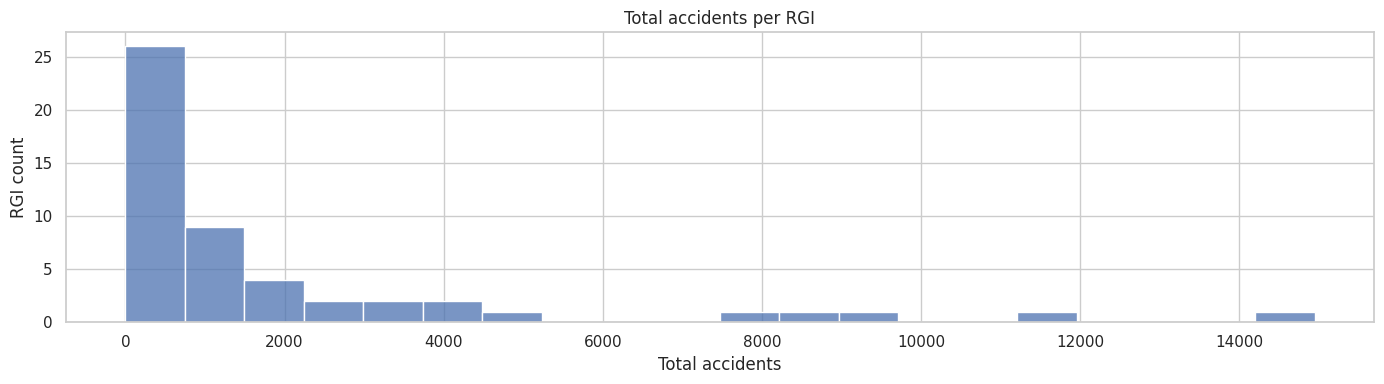

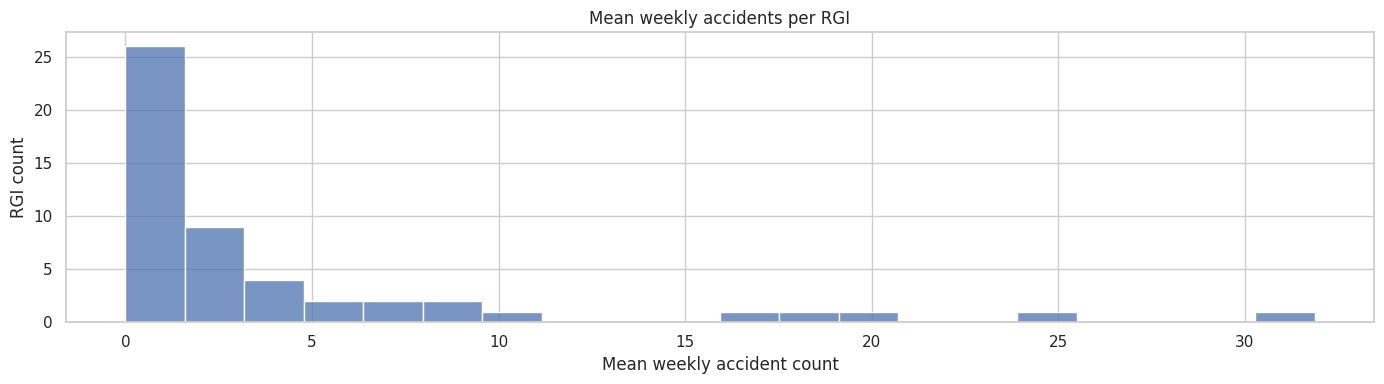

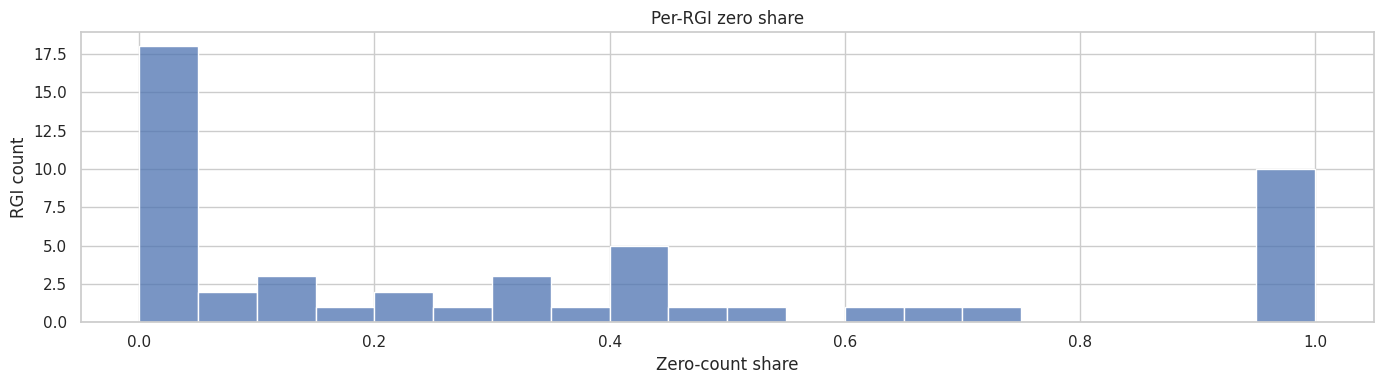

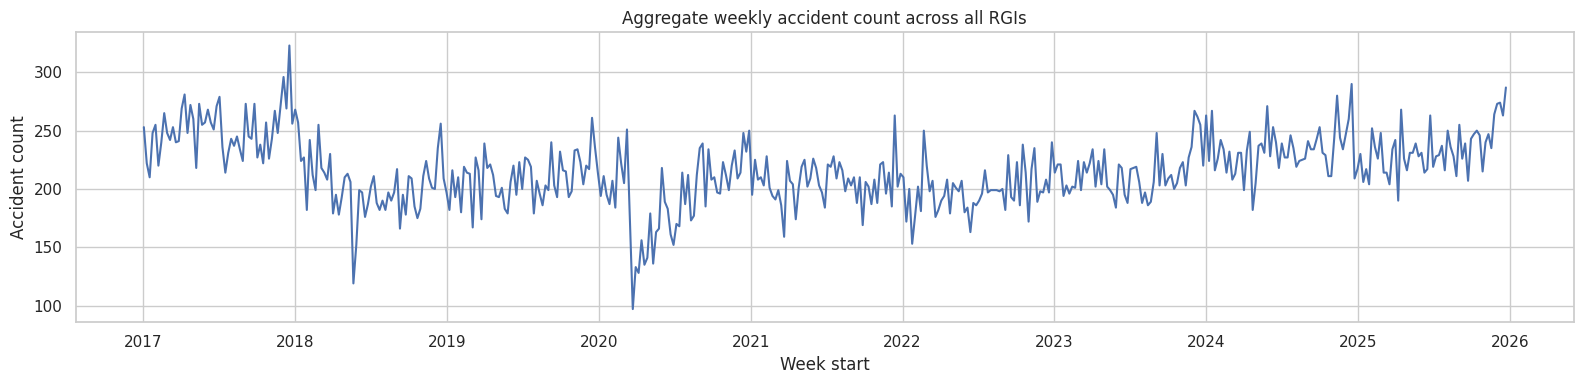

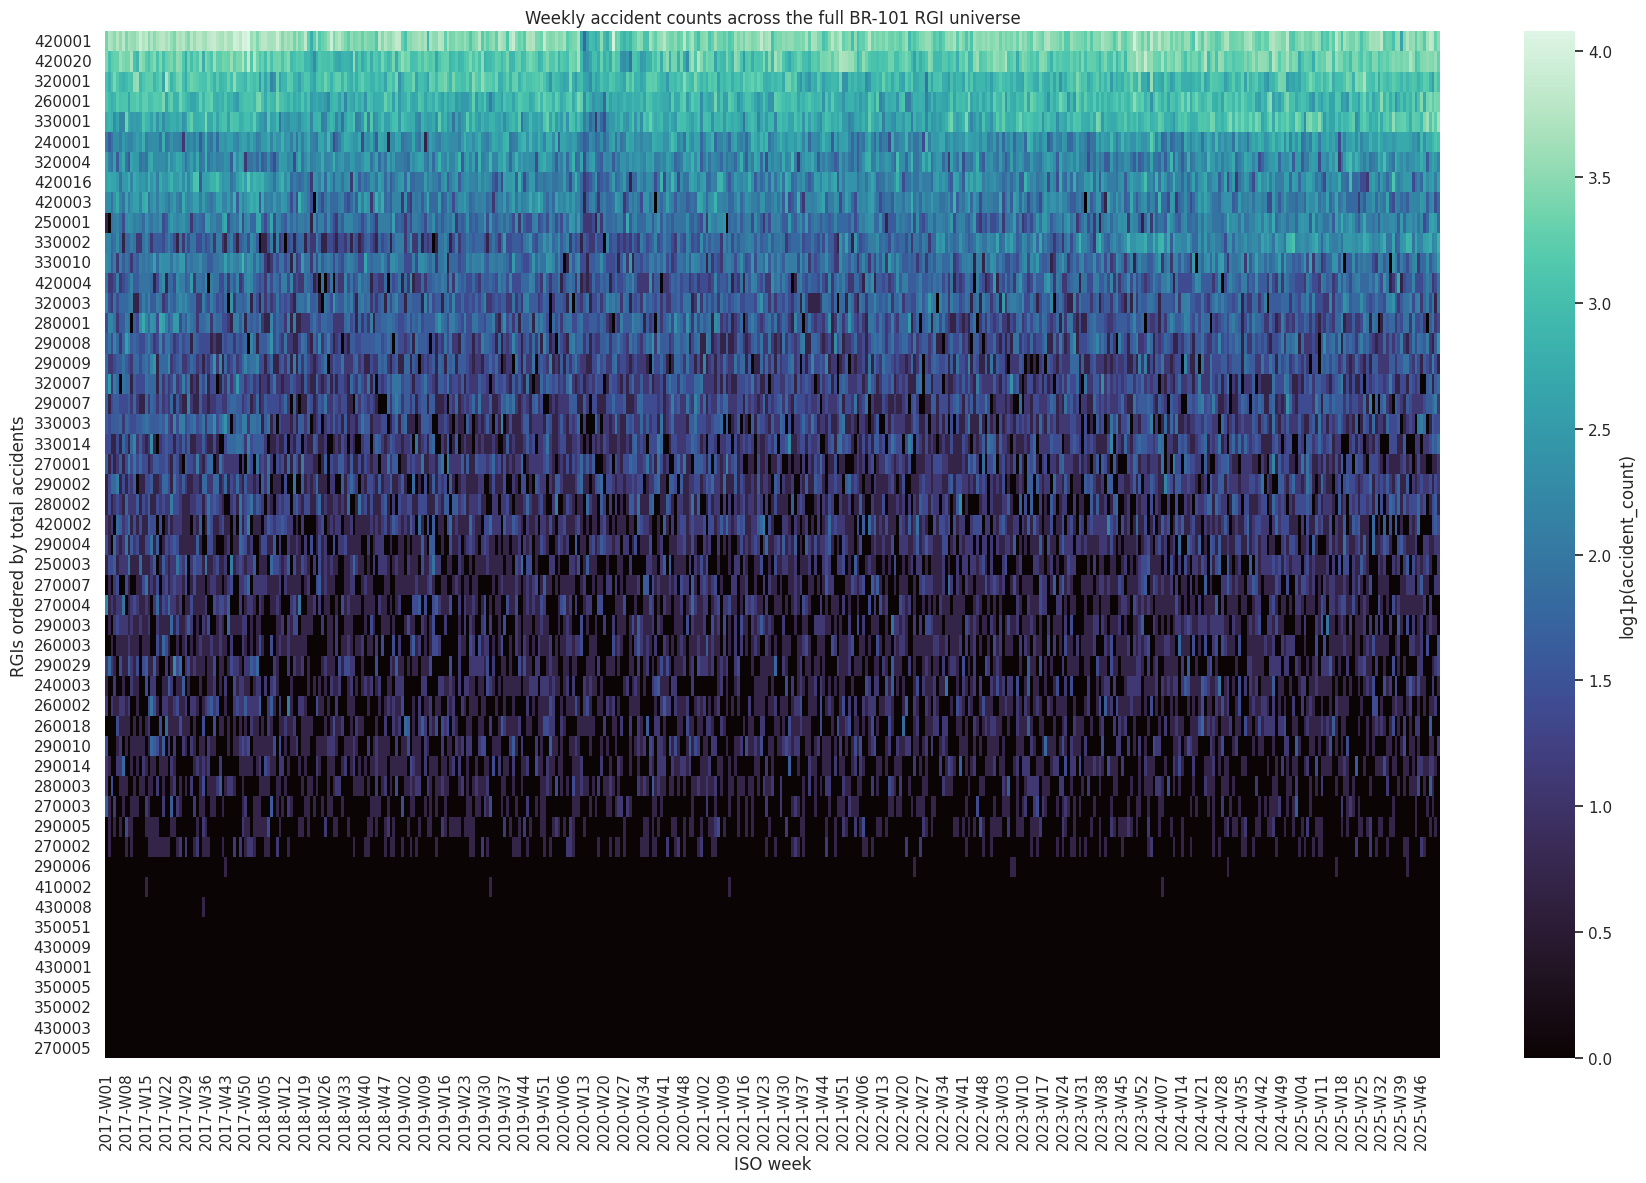

In [9]:
panel_diagnostics = build_panel_diagnostics(weekly_rgi_panel)
panel_diagnostics.to_parquet(CONFIG.silver_output_dir / 'panel_diagnostics.parquet', index=False)

display(panel_diagnostics.head(20))
plot_panel_diagnostics(weekly_rgi_panel)


In [10]:
baseline_validation_forecasts = generate_baseline_forecasts(weekly_rgi_panel, CONFIG, split='validation')
baseline_test_forecasts = generate_baseline_forecasts(weekly_rgi_panel, CONFIG, split='test')

baseline_validation_forecasts.to_parquet(
    CONFIG.gold_output_dir / 'baseline_validation_forecasts.parquet',
    index=False,
)
baseline_test_forecasts.to_parquet(
    CONFIG.gold_output_dir / 'baseline_test_forecasts.parquet',
    index=False,
)

display(baseline_validation_forecasts.head())
display(baseline_test_forecasts.head())


,model,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,moving_average_4w,validation,240001,Natal,RN,2024-01-01,2024-01-07,2024-W01,2024-01-01,2023-12-04,1,11.0,10.0,True,history_rows=4
1,moving_average_4w,validation,240001,Natal,RN,2024-01-08,2024-01-14,2024-W02,2024-01-01,2023-12-04,2,11.0,12.0,True,history_rows=4
2,moving_average_4w,validation,240001,Natal,RN,2024-01-15,2024-01-21,2024-W03,2024-01-01,2023-12-04,3,11.0,24.0,True,history_rows=4
3,moving_average_4w,validation,240001,Natal,RN,2024-01-22,2024-01-28,2024-W04,2024-01-01,2023-12-04,4,11.0,16.0,True,history_rows=4
4,moving_average_4w,validation,240001,Natal,RN,2024-01-29,2024-02-04,2024-W05,2024-01-29,2024-01-01,1,11.5,8.0,True,history_rows=4


,model,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,moving_average_4w,test,240001,Natal,RN,2024-12-30,2025-01-05,2025-W01,2024-12-30,2024-12-02,1,15.75,14.0,True,history_rows=4
1,moving_average_4w,test,240001,Natal,RN,2025-01-06,2025-01-12,2025-W02,2024-12-30,2024-12-02,2,15.75,10.0,True,history_rows=4
2,moving_average_4w,test,240001,Natal,RN,2025-01-13,2025-01-19,2025-W03,2024-12-30,2024-12-02,3,15.75,16.0,True,history_rows=4
3,moving_average_4w,test,240001,Natal,RN,2025-01-20,2025-01-26,2025-W04,2024-12-30,2024-12-02,4,15.75,6.0,True,history_rows=4
4,moving_average_4w,test,240001,Natal,RN,2025-01-27,2025-02-02,2025-W05,2025-01-27,2024-12-30,1,12.00,7.0,True,history_rows=4


In [ ]:
sarima_timer = perf_counter()
sarima_candidate_grid = build_sarima_candidate_grid(CONFIG)
sarima_fit_diagnostics, best_sarima_specs = select_best_sarima_specs(
    weekly_rgi_panel,
    CONFIG,
    candidate_grid=sarima_candidate_grid,
)
sarima_validation_forecasts = generate_sarima_forecasts(
    weekly_rgi_panel,
    CONFIG,
    best_sarima_specs,
    split='validation',
)
sarima_test_forecasts = generate_sarima_forecasts(
    weekly_rgi_panel,
    CONFIG,
    best_sarima_specs,
    split='test',
)

sarima_fit_diagnostics.to_parquet(CONFIG.gold_output_dir / 'sarima_fit_diagnostics.parquet', index=False)
sarima_validation_forecasts.to_parquet(CONFIG.gold_output_dir / 'sarima_validation_forecasts.parquet', index=False)
sarima_test_forecasts.to_parquet(CONFIG.gold_output_dir / 'sarima_test_forecasts.parquet', index=False)

elapsed = perf_counter() - sarima_timer
print(f'SARIMA runtime: {elapsed:,.1f} seconds')
print(f'RGIs with selected SARIMA specs: {len(best_sarima_specs):,}')
print(f'Validation forecast rows: {sarima_validation_forecasts["prediction"].notna().sum():,}')
print(f'Test forecast rows: {sarima_test_forecasts["prediction"].notna().sum():,}')
display(sarima_fit_diagnostics.head())


In [11]:
rnn_datasets = prepare_rnn_datasets(weekly_rgi_panel, CONFIG)
train_bundle = rnn_datasets['train']
validation_bundle = rnn_datasets['validation']
test_bundle = rnn_datasets['test']
entity_encoders = rnn_datasets['encoders']

print('Train history shape:', train_bundle['inputs']['history'].shape)
print('Validation history shape:', validation_bundle['inputs']['history'].shape)
print('Test history shape:', test_bundle['inputs']['history'].shape)
print('Number of encoded RGIs:', len(entity_encoders['rgi_id']))
print('Number of encoded UFs:', len(entity_encoders['uf']))


Train history shape: (15657, 52, 1)
Validation history shape: (663, 52, 1)
Test history shape: (663, 52, 1)
Number of encoded RGIs: 51
Number of encoded UFs: 12


In [13]:
train_bundle.keys()

dict_keys(['inputs', 'targets', 'meta', 'split'])

In [15]:
train_bundle['inputs'].keys()

dict_keys(['history', 'future_holiday', 'road_length', 'rgi_id', 'uf_id'])

In [21]:
train_bundle['inputs']['uf_id']

array([7, 7, 7, ..., 8, 8, 8], shape=(15657,), dtype=int32)

In [27]:
train_bundle['inputs']['history']

array([[[ 7.],
        [ 4.],
        [ 6.],
        ...,
        [12.],
        [ 9.],
        [13.]],

       [[ 4.],
        [ 6.],
        [ 9.],
        ...,
        [ 9.],
        [13.],
        [10.]],

       [[ 6.],
        [ 9.],
        [ 9.],
        ...,
        [13.],
        [10.],
        [ 7.]],

       ...,

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]]], shape=(15657, 52, 1), dtype=float32)

In [22]:
if tf is None:
    raise ModuleNotFoundError(tensorflow_status_message())

rnn_training_artifacts = train_rnn_model(
    train_bundle,
    validation_bundle,
    CONFIG,
    n_rgis=len(entity_encoders['rgi_id']),
    n_ufs=len(entity_encoders['uf']),
)
display(pd.DataFrame(rnn_training_artifacts['history']).tail())


E0000 00:00:1774965462.434537   52335 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


RNN training: 0epoch [00:00, ?epoch/s]

,loss,rmse,val_loss,val_rmse
1,5.353349,2.313730,6.127560,2.475391
2,5.280751,2.297988,6.193884,2.488752
3,5.246713,2.290570,6.228840,2.495764
4,5.221712,2.285107,6.282779,2.506547
5,5.207312,2.281954,6.327610,2.515474


In [23]:
if tf is None:
    raise ModuleNotFoundError(tensorflow_status_message())

rnn_validation_forecasts = generate_rnn_forecasts(
    rnn_training_artifacts['model'],
    validation_bundle,
    split='validation',
)
rnn_test_forecasts = generate_rnn_forecasts(
    rnn_training_artifacts['model'],
    test_bundle,
    split='test',
)

rnn_validation_forecasts.to_parquet(CONFIG.gold_output_dir / 'rnn_validation_forecasts.parquet', index=False)
rnn_test_forecasts.to_parquet(CONFIG.gold_output_dir / 'rnn_test_forecasts.parquet', index=False)

display(rnn_validation_forecasts.head())
display(rnn_test_forecasts.head())


,model,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,rnn_global,validation,240001,Natal,RN,2024-01-01,2024-01-07,2024-W01,2024-01-01,2023-12-04,1,10.700235,10.0,True,tensorflow_gru
1,rnn_global,validation,240001,Natal,RN,2024-01-08,2024-01-14,2024-W02,2024-01-01,2023-12-04,2,10.694839,12.0,True,tensorflow_gru
2,rnn_global,validation,240001,Natal,RN,2024-01-15,2024-01-21,2024-W03,2024-01-01,2023-12-04,3,9.832367,24.0,True,tensorflow_gru
3,rnn_global,validation,240001,Natal,RN,2024-01-22,2024-01-28,2024-W04,2024-01-01,2023-12-04,4,10.686622,16.0,True,tensorflow_gru
4,rnn_global,validation,240001,Natal,RN,2024-01-29,2024-02-04,2024-W05,2024-01-29,2024-01-01,1,10.768946,8.0,True,tensorflow_gru


,model,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,rnn_global,test,240001,Natal,RN,2024-12-30,2025-01-05,2025-W01,2024-12-30,2024-12-02,1,12.638891,14.0,True,tensorflow_gru
1,rnn_global,test,240001,Natal,RN,2025-01-06,2025-01-12,2025-W02,2024-12-30,2024-12-02,2,12.567310,10.0,True,tensorflow_gru
2,rnn_global,test,240001,Natal,RN,2025-01-13,2025-01-19,2025-W03,2024-12-30,2024-12-02,3,11.844801,16.0,True,tensorflow_gru
3,rnn_global,test,240001,Natal,RN,2025-01-20,2025-01-26,2025-W04,2024-12-30,2024-12-02,4,12.590896,6.0,True,tensorflow_gru
4,rnn_global,test,240001,Natal,RN,2025-01-27,2025-02-02,2025-W05,2025-01-27,2024-12-30,1,11.846193,7.0,True,tensorflow_gru


In [24]:
forecast_frames = [
    baseline_validation_forecasts,
    baseline_test_forecasts,
    # sarima_validation_forecasts,
    # sarima_test_forecasts,
]
if 'rnn_validation_forecasts' in globals():
    forecast_frames.append(rnn_validation_forecasts)
if 'rnn_test_forecasts' in globals():
    forecast_frames.append(rnn_test_forecasts)

combined_forecasts = combine_forecasts(*forecast_frames)
benchmark_metrics, rgi_level_metrics = evaluate_forecasts(weekly_rgi_panel, combined_forecasts)

benchmark_metrics.to_parquet(CONFIG.gold_output_dir / 'benchmark_metrics.parquet', index=False)
benchmark_metrics.to_csv(CONFIG.gold_output_dir / 'benchmark_metrics.csv', index=False)
rgi_level_metrics.to_parquet(CONFIG.gold_output_dir / 'rgi_level_metrics.parquet', index=False)

display(benchmark_metrics.sort_values(['split', 'rmse']))
display(rgi_level_metrics.sort_values(['split', 'model', 'rmse'], ascending=[True, True, False]).head(20))


,model,split,rmse,n_predictions,n_rgis_with_predictions,macro_rgi_rmse,n_target_rows,forecast_row_coverage
2,rnn_global,test,2.604477,2652.0,51.0,1.890966,2652,1.0
0,moving_average_4w,test,2.765979,2652.0,51.0,1.979757,2652,1.0
4,seasonal_naive,test,3.330070,2652.0,51.0,2.441680,2652,1.0
3,rnn_global,validation,2.457936,2652.0,51.0,1.810434,2652,1.0
1,moving_average_4w,validation,2.536758,2652.0,51.0,1.868503,2652,1.0
5,seasonal_naive,validation,3.171149,2652.0,51.0,2.348807,2652,1.0


,model,split,rgi_id,rgi_name,uf,n_predictions,rmse,expected_rows,forecast_row_coverage
41,moving_average_4w,test,420001,Florianópolis,SC,52,7.979240,52,1.0
32,moving_average_4w,test,330001,Rio de Janeiro,RJ,52,7.015094,52,1.0
4,moving_average_4w,test,260001,Recife,PE,52,6.585970,52,1.0
46,moving_average_4w,test,420020,Itajaí,SC,52,6.296366,52,1.0
28,moving_average_4w,test,320001,Vitória,ES,52,5.856456,52,1.0
45,moving_average_4w,test,420016,Joinville,SC,52,4.246039,52,1.0
33,moving_average_4w,test,330002,Angra dos Reis,RJ,52,4.050760,52,1.0
30,moving_average_4w,test,320004,Linhares,ES,52,3.986154,52,1.0
0,moving_average_4w,test,240001,Natal,RN,52,3.874845,52,1.0
35,moving_average_4w,test,330010,Campos dos Goytacazes,RJ,52,2.913001,52,1.0


In [25]:
combined_forecasts["rgi_id"].drop_duplicates()

0       240001
52      240003
104     250001
156     250003
208     260001
260     260002
312     260003
364     260018
416     270001
468     270002
520     270003
572     270004
624     270005
676     270007
728     280001
780     280002
832     280003
884     290002
936     290003
988     290004
1040    290005
1092    290006
1144    290007
1196    290008
1248    290009
1300    290010
1352    290014
1404    290029
1456    320001
1508    320003
1560    320004
1612    320007
1664    330001
1716    330002
1768    330003
1820    330010
1872    330014
1924    350002
1976    350005
2028    350051
2080    410002
2132    420001
2184    420002
2236    420003
2288    420004
2340    420016
2392    420020
2444    430001
2496    430003
2548    430008
2600    430009
Name: rgi_id, dtype: str

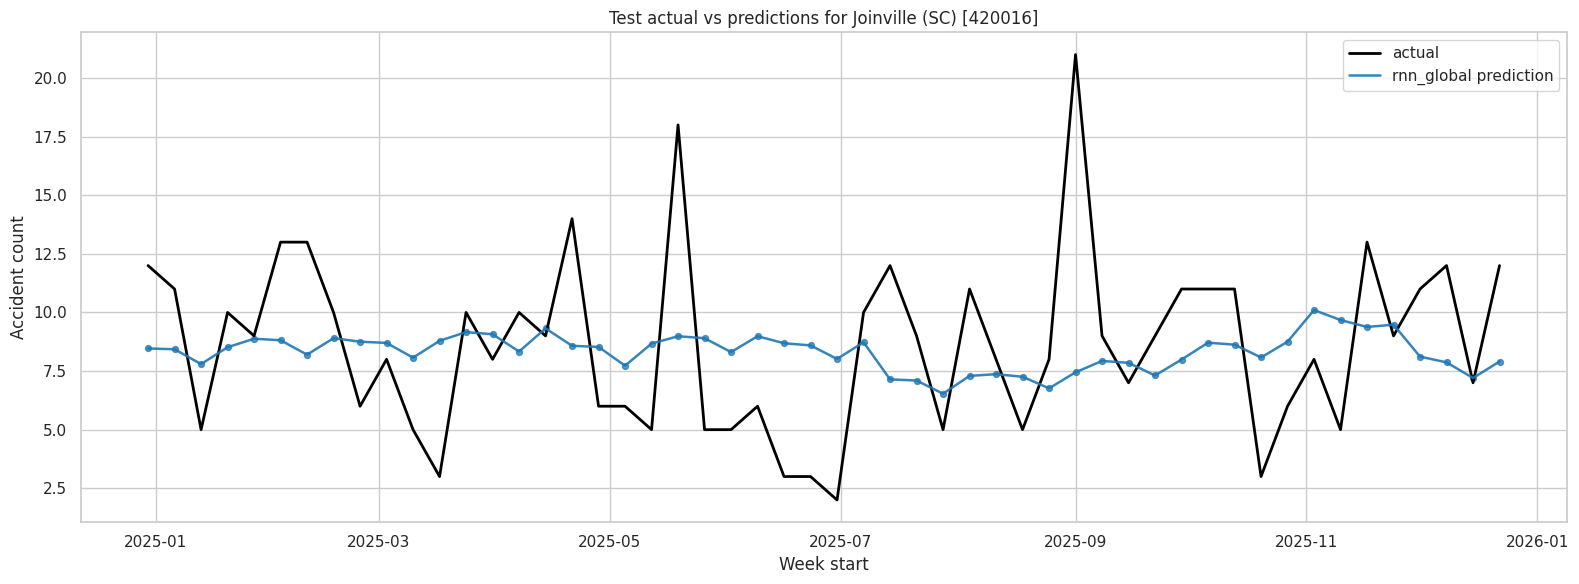

,model,horizon_step,horizon_label,rmse,n_predictions
0,rnn_global,1,q1,3.989337,13.0
1,rnn_global,2,q2,3.195044,13.0
2,rnn_global,3,q3,3.268428,13.0
3,rnn_global,4,q4,4.740091,13.0


In [26]:
# Example: visualize one RGI's test forecasts and inspect horizon-specific RMSE.
# Replace the RGI id and model name as needed.
rgi_test_horizon_rmse = plot_test_predictions_for_rgi(
    weekly_rgi_panel,
    combined_forecasts,
    rgi_id='420016',
    model='rnn_global',
    split='test',
)
display(rgi_test_horizon_rmse)


## Closing Notes

After execution, summarize here:

- which benchmark won on validation and test
- whether weekly sparsity appears manageable
- immediate first-pass limitations
- what remains deferred to notebook 4
